# Задание 1

In [2]:
import os
import random
import sys
import re
import numpy as np
import pandas as pd
import torch
import torchvision
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from PIL import Image
from tqdm import tqdm
from glob import glob
import cv2
from sklearn.model_selection import GroupShuffleSplit
import albumentations as A
from albumentations.pytorch import ToTensorV2

print("Environment Versions:")
print(f"Python: {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA Version: {torch.version.cuda}")

def seed_everything(seed=42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

seed_everything(42)

folders = [
    "data/raw",
    "data/interim",
    "data/processed",
    "splits",
    "artifacts/checkpoints",
    "artifacts/preds",
    "artifacts/reports",
    "artifacts/figures",
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print(f"Successfully created {len(folders)} project directories.")

Environment Versions:
Python: 3.12.12
PyTorch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
CUDA Available: True
CUDA Version: 12.8
Successfully created 8 project directories.


# Задание 2

In [7]:
CSV_PATH = "/kaggle/input/datasets/danilbarantsov/simlis-data/cu_data/selected_by_name_iimk_subset_public.csv"
IMAGE_ROOT_DIR = "/kaggle/input/datasets/danilbarantsov/simlis-data/cu_data/dataset"

print("-" * 30)
print("Проверка путей:")
print(f"CSV файл: {CSV_PATH} | Существует: {os.path.exists(CSV_PATH)}")
print(f"Корень изображений: {IMAGE_ROOT_DIR} | Существует: {os.path.exists(IMAGE_ROOT_DIR)}")

if os.path.exists(CSV_PATH) and os.path.exists(IMAGE_ROOT_DIR):
    df = pd.read_csv(CSV_PATH)
    print(f"\nКоличество строк в основном CSV: {len(df)}")
    all_files = glob(os.path.join(IMAGE_ROOT_DIR, "**", "*.*"), recursive=True)
    valid_extensions = {".jpg", ".jpeg", ".png"}
    image_files = [f for f in all_files if os.path.splitext(f)[1].lower() in valid_extensions]
    print(f"Количество файлов изображений на диске: {len(image_files)}")
else:
    print("\nДанные не найдены! Проверь пути.")

------------------------------
Проверка путей:
CSV файл: /kaggle/input/datasets/danilbarantsov/simlis-data/cu_data/selected_by_name_iimk_subset_public.csv | Существует: True
Корень изображений: /kaggle/input/datasets/danilbarantsov/simlis-data/cu_data/dataset | Существует: True

Количество строк в основном CSV: 1389
Количество файлов изображений на диске: 1388


# Задание 3

In [10]:
df = pd.read_csv(CSV_PATH)
print("Всего колонок:", len(df.columns))
print("Список колонок:\n", df.columns.tolist())
print("-" * 30)

all_files = glob(os.path.join(IMAGE_ROOT_DIR, "**", "*.*"), recursive=True)
image_files = [f for f in all_files if f.lower().endswith((".png", ".jpg", ".jpeg"))]
print(f"Найдено файлов изображений: {len(image_files)}")

if len(image_files) == 0:
    print("\n[ВНИМАНИЕ] Не найдено ни одного изображения! Проверьте путь IMAGE_ROOT_DIR")
    print(f"Содержимое {IMAGE_ROOT_DIR}:")
    print(os.listdir(IMAGE_ROOT_DIR)[:20])
else:
    print(f"Примеры имен файлов:")
    for f in image_files[:5]:
        print(f"  {os.path.basename(f)}")

def extract_code_from_filename(filename):
    name = os.path.splitext(os.path.basename(filename))[0]
    parts = name.split('_')
    if len(parts) >= 2:
        return parts[1]
    return name

file_dict = {}
for f in image_files:
    code = extract_code_from_filename(f)
    if code not in file_dict:
        file_dict[code] = f
    else:
        pass

print(f"\nСоздано mapping-записей: {len(file_dict)}")
print(f"Примеры mapping:")
for i, (k, v) in enumerate(file_dict.items()):
    if i >= 5:
        break
    print(f"  {k} -> {os.path.basename(v)}")

df["code_str"] = df["code"].astype(str).str.strip()
df["full_image_path"] = df["code_str"].map(file_dict)
df["path_exists"] = df["full_image_path"].notnull()

valid_paths_count = df["path_exists"].sum()
broken_paths_count = len(df) - valid_paths_count
duplicated_images = (df["full_image_path"].value_counts() > 1).sum()
duplicated_ids = df["code"].duplicated().sum()

print(f"\nКлючевое поле ID: 'code'")
print(f"Строк с валидным путем к картинке: {valid_paths_count}")
print(f"Битых путей (картинка не найдена): {broken_paths_count}")
print(f"Дубликатов изображений (одно фото на разные строки): {duplicated_images}")
print(f"Повторов по предмету (колонка 'code'): {duplicated_ids}")
print("-" * 30)

if valid_paths_count > 0:
    print("\nОтрисовка 3 примеров...")
    valid_rows = df[df["path_exists"]].head(3)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, (_, row) in zip(axes, valid_rows.iterrows()):
        img_path = row["full_image_path"]
        img = Image.open(img_path)
        ax.imshow(img)
        ax.axis("off")
        title_text = f"Code: {row['code']}\nName: {str(row['name'])[:40]}..."
        ax.set_title(title_text, fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("\n[ВНИМАНИЕ] Сопоставление не удалось. Нужно проверить логику сопоставления.")
    print("Примеры code из CSV:")
    print(df["code"].head(10).tolist())

Всего колонок: 10
Список колонок:
 ['Unnamed: 0', 'code', 'name', 'description', 'material', 'size', 'fragm', 'cultlayer', 'execorg', 'survyear']
------------------------------
Найдено файлов изображений: 1388
Примеры имен файлов:
  М102-2012-2-1327_orig.jpg
  БП12-Г01-6525_orig.jpg
  КБ-2014-Р1-0400_orig.jpg
  Нейш3А-2018-2759_orig.jpg
  Нейш3А-2018-0384_orig.jpg

Создано mapping-записей: 1
Примеры mapping:
  orig -> М102-2012-2-1327_orig.jpg

Ключевое поле ID: 'code'
Строк с валидным путем к картинке: 0
Битых путей (картинка не найдена): 1389
Дубликатов изображений (одно фото на разные строки): 0
Повторов по предмету (колонка 'code'): 1
------------------------------

[ВНИМАНИЕ] Сопоставление не удалось. Нужно проверить логику сопоставления.
Примеры code из CSV:
['М102-2012-1-0494', 'М102-2012-1-0496', 'М102-2012-1-0529', 'М102-2012-1-0585', 'М102-2012-1-0603', 'М102-2012-1-0611', 'М102-2012-1-0691', 'М102-2012-1-0752', 'М102-2012-1-0827', 'М102-2012-1-0833']


# Задание 4

1. Собираем размеры изображений...


0it [00:00, ?it/s]


IndexError: index 0 is out of bounds for axis 0 with size 0

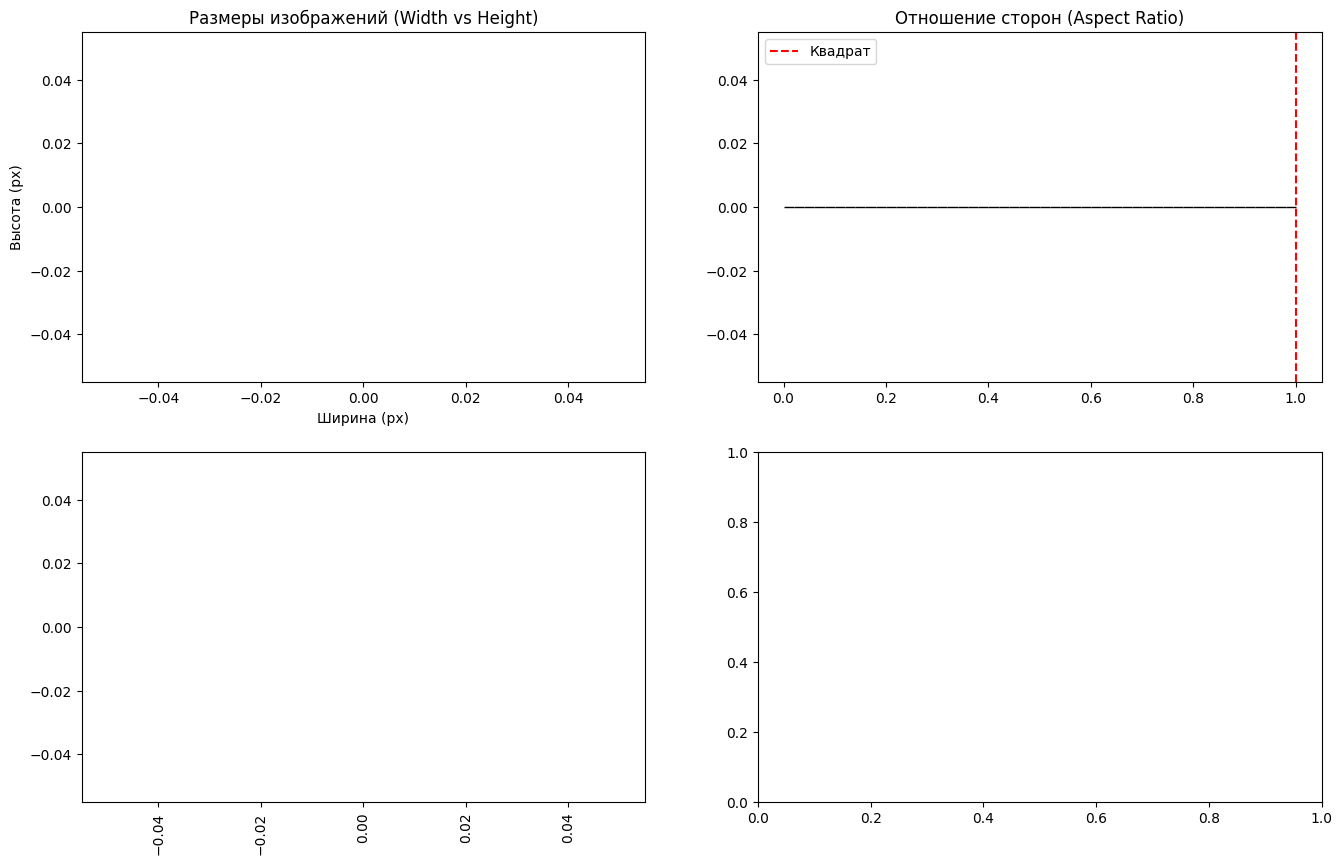

In [11]:
Image.MAX_IMAGE_PIXELS = None
valid_df = df[df["path_exists"]].copy()

print("1. Собираем размеры изображений...")
widths, heights, aspects = [], [], []
for path in tqdm(valid_df["full_image_path"]):
    with Image.open(path) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)
        aspects.append(w / h)

valid_df["width"] = widths
valid_df["height"] = heights
valid_df["aspect_ratio"] = aspects

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].scatter(valid_df["width"], valid_df["height"], alpha=0.5, s=15, color="purple")
axes[0, 0].set_title("Размеры изображений (Width vs Height)")
axes[0, 0].set_xlabel("Ширина (px)")
axes[0, 0].set_ylabel("Высота (px)")

axes[0, 1].hist(valid_df["aspect_ratio"], bins=50, color="skyblue", edgecolor="black")
axes[0, 1].set_title("Отношение сторон (Aspect Ratio)")
axes[0, 1].axvline(1.0, color="red", linestyle="--", label="Квадрат")
axes[0, 1].legend()

valid_df["code"].value_counts().value_counts().sort_index().plot(kind="bar", ax=axes[1, 0], color="orange")
axes[1, 0].set_title("Количество ракурсов/фото на один артефакт")
axes[1, 0].set_xlabel("Число фото у предмета")
axes[1, 0].set_ylabel("Количество артефактов")

valid_df["material"].fillna("Нет данных").value_counts().head(10).plot(kind="bar", ax=axes[1, 1], color="salmon")
axes[1, 1].set_title("Топ-10 категорий: Material")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print("\n2. Отрисовка сетки 12 случайных изображений...")
sample_12 = valid_df.sample(12, random_state=42)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for ax, (_, row) in zip(axes.flatten(), sample_12.iterrows()):
    img = Image.open(row["full_image_path"])
    ax.imshow(img)
    ax.axis("off")
    mat = str(row["material"])[:15] if pd.notna(row["material"]) else "None"
    frag = str(row["fragm"])[:15] if pd.notna(row["fragm"]) else "None"
    title = f"ID: {row['code']}\nMat: {mat} | Fr: {frag}\nSize: {row['width']}x{row['height']}"
    ax.set_title(title, fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
Image.MAX_IMAGE_PIXELS = None

print("Анализ эвристик на подвыборке из 50 изображений...")
subset_50 = valid_df.sample(50, random_state=77).copy()

brightness_list = []
fg_ratio_list = []
bg_types = []

for path in tqdm(subset_50["full_image_path"]):
    img_array = np.fromfile(path, dtype=np.uint8)
    img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
    if img is None:
        pil_img = Image.open(path).convert("RGB")
        img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    brightness = np.mean(gray)
    brightness_list.append(brightness)

    _, thresh = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY_INV)
    fg_ratio = np.sum(thresh == 255) / thresh.size
    fg_ratio_list.append(fg_ratio)

    corners = [gray[0, 0], gray[0, -1], gray[-1, 0], gray[-1, -1]]
    avg_bg_color = np.mean(corners)
    if avg_bg_color > 230:
        bg_types.append("White")
    elif avg_bg_color > 180:
        bg_types.append("Light-Gray")
    else:
        bg_types.append("Other/Dark")

subset_50["brightness"] = brightness_list
subset_50["fg_ratio"] = fg_ratio_list
subset_50["bg_type"] = bg_types

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

darkest = subset_50.sort_values("brightness").head(3)
for i, (_, row) in enumerate(darkest.iterrows()):
    axes[0, i].imshow(Image.open(row["full_image_path"]))
    axes[0, i].set_title(f"Плохой свет (Темные)\nЯркость: {row['brightness']:.0f}/255")
    axes[0, i].axis("off")

smallest_fg = subset_50.sort_values("fg_ratio").head(3)
for i, (_, row) in enumerate(smallest_fg.iterrows()):
    axes[1, i].imshow(Image.open(row["full_image_path"]))
    axes[1, i].set_title(f"Мелкий объект / Много фона\nFG Ratio: {row['fg_ratio']:.1%}")
    axes[1, i].axis("off")

weird_aspect = subset_50[(subset_50["aspect_ratio"] > 2.0) | (subset_50["aspect_ratio"] < 0.5)].head(3)
for i, (_, row) in enumerate(weird_aspect.iterrows()):
    axes[2, i].imshow(Image.open(row["full_image_path"]))
    axes[2, i].set_title(f"Сильный кроп (Aspect Ratio)\nОтношение: {row['aspect_ratio']:.2f}")
    axes[2, i].axis("off")

plt.tight_layout()
plt.show()

print("\nСтатистика по типам фона (из 50 фото):")
print(subset_50["bg_type"].value_counts())

# Задание 5

In [1]:
valid_df = df[df["path_exists"]].copy()

print("--- 1. Вывод 15 примеров реальных описаний ---")
sample_texts = valid_df.dropna(subset=["description"]).sample(15, random_state=42)

for idx, row in sample_texts.iterrows():
    mat = str(row["material"]) if pd.notna(row["material"]) else "Нет"
    frag = str(row["fragm"]) if pd.notna(row["fragm"]) else "Нет"
    desc = str(row["description"]).replace("\n", " ")
    print(f"ID: {row['code']}")
    print(f"  Тип (name): {row['name']}")
    print(f"  Мат-л/Целостность: {mat} | {frag}")
    print(f"  Описание: {desc}")
    print("-" * 60)

print("\n--- 2. Анализ кандидатов и формирование таблицы ---")

candidates_data = [
    {
        "field_name": "fragm (Целостность)",
        "почему это поле визуально видно": "Легко отличить целый предмет от его фрагмента. Форма и обрывы краев явно читаются на фото.",
        "тип цели": "single-label",
        "грубое число классов": f"~{valid_df['fragm'].nunique()} (потребуется сведение к 3-4 основным)",
        "доля пропусков": f"{(valid_df['fragm'].isna().sum() / len(valid_df)):.1%}",
        "риск неоднозначности": "Низкий. Визуальные признаки целостности однозначны.",
    },
    {
        "field_name": "material (Материал)",
        "почему это поле визуально видно": "Текстура, блеск глазури, сколы и цвет поверхности позволяют визуально отличить керамику от стекла или дерева.",
        "тип цели": "single-label",
        "грубое число классов": f"~{valid_df['material'].nunique()} (потребуется нормализация)",
        "доля пропусков": f"{(valid_df['material'].isna().sum() / len(valid_df)):.1%}",
        "риск неоднозначности": "Средний. При плохом свете легко спутать фаянс и фарфор.",
    },
    {
        "field_name": "name (Тип/Часть)",
        "почему это поле визуально видно": "Геометрия предмета напрямую указывает на его тип.",
        "тип цели": "single-label",
        "грубое число классов": f"~{valid_df['name'].nunique()} (очень много, нужен жесткий парсинг)",
        "доля пропусков": f"{(valid_df['name'].isna().sum() / len(valid_df)):.1%}",
        "риск неоднозначности": "Высокий из-за обилия синонимов в сырых данных.",
    },
    {
        "field_name": "description (Функция/Детали)",
        "почему это поле визуально видно": "НЕТ. Невозможно надежно извлечь.",
        "тип цели": "лучше не брать в baseline",
        "грубое число классов": "-",
        "доля пропусков": f"{(valid_df['description'].isna().sum() / len(valid_df)):.1%}",
        "риск неоднозначности": "Критический. Текст содержит исторический контекст, невидимый глазу.",
    },
    {
        "field_name": "cultlayer / survyear (Контекст)",
        "почему это поле визуально видно": "НЕТ. Это метаданные раскопа.",
        "тип цели": "лучше не брать в baseline",
        "грубое число классов": "-",
        "доля пропусков": "-",
        "риск неоднозначности": "100% зависимость от внешнего контекста.",
    },
]

df_candidates = pd.DataFrame(candidates_data)
display(df_candidates)

print("--- Топ-15 сырых значений в поле Material ---")
print(valid_df["material"].value_counts(dropna=False).head(15))

print("\n--- Топ-15 сырых значений в поле Fragm ---")
print(valid_df["fragm"].value_counts(dropna=False).head(15))

NameError: name 'df' is not defined

# Задание 6

In [ ]:
print("--- 1. Создание словарей нормализации ---")

material_dict = {
    "керамика": "керамика",
    "фаянс": "фаянс",
    "фарфор": "фарфор",
    "стекло": "стекло",
    "глина": "глина",
    "красноглиняная керамика": "керамика",
    "белоглиняная керамика": "керамика",
    "светлоглиняная керамика": "керамика",
}

fragm_dict = {
    "фрагмент": "фрагмент",
    "целый": "целый",
    "фр.": "фрагмент",
    "фр": "фрагмент",
    "целая форма": "целый",
}

print("Пример обработки (Материал): 'красноглиняная керамика' -> 'керамика'")
print("Пример обработки (Целостность): 'фр.' -> 'фрагмент'")
print("-" * 50)

def normalize_feature(df, col_name, mapping_dict, rare_label="прочее"):
    raw_col = f"raw_{col_name}"
    norm_col = f"norm_{col_name}"
    missing_col = f"{col_name}_is_missing"
    uncertain_col = f"{col_name}_is_uncertain"

    df[raw_col] = df[col_name].copy()
    cleaned_raw = df[col_name].astype(str).str.lower().str.strip()

    df[missing_col] = (
        df[col_name].isna()
        | (cleaned_raw == "nan")
        | (cleaned_raw == "")
        | (cleaned_raw == "none")
    )

    df[norm_col] = cleaned_raw.map(mapping_dict)
    mask_unmapped = df[norm_col].isna() & ~df[missing_col]
    df.loc[mask_unmapped, norm_col] = rare_label
    df.loc[df[missing_col], norm_col] = "неизвестно"
    df[uncertain_col] = (
        df[missing_col] | (df[norm_col] == rare_label) | (df[norm_col] == "неизвестно")
    )

    return df

valid_df = normalize_feature(valid_df, "material", material_dict, rare_label="прочее")
valid_df = normalize_feature(valid_df, "fragm", fragm_dict, rare_label="неизвестно")

print("\n--- 2. Результат сборки колонок (пример для Материала) ---")
display(
    valid_df[
        [
            "raw_material",
            "norm_material",
            "material_is_missing",
            "material_is_uncertain",
        ]
    ].head()
)

print("\n--- 3. Распределение классов после нормализации ---")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

valid_df["norm_material"].value_counts().plot(
    kind="bar", color="salmon", edgecolor="black", ax=axes[0]
)
axes[0].set_title(
    f"Нормализованный 'material'\nКлассов: {valid_df['norm_material'].nunique()}"
)
axes[0].tick_params(axis="x", rotation=45)

valid_df["norm_fragm"].value_counts().plot(
    kind="bar", color="lightgreen", edgecolor="black", ax=axes[1]
)
axes[1].set_title(
    f"Нормализованный 'fragm'\nКлассов: {valid_df['norm_fragm'].nunique()}"
)
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

# Задание 7

In [ ]:
def generate_auto_description(preds, confs, thresholds):
    fragm_val = preds.get('fragm', 'неизвестно')
    fragm_conf = confs.get('fragm', 0.0)
    if fragm_conf < thresholds['uncertain'] or fragm_val == 'неизвестно':
        text_fragm = "Предмет неизвестной сохранности"
    else:
        text_fragm = fragm_val.capitalize()

    name_val = preds.get('name', 'предмет')
    name_conf = confs.get('name', 0.0)
    if name_conf < thresholds['uncertain'] or name_val == 'неизвестно':
        text_name = "неустановленного типа"
    elif name_conf < thresholds['certain']:
        text_name = f"типа '{name_val}' (предположительно)"
    else:
        text_name = f"типа '{name_val}'"

    mat_val = preds.get('material', 'неизвестно')
    mat_conf = confs.get('material', 0.0)
    if mat_conf < thresholds['uncertain'] or mat_val == 'неизвестно' or mat_val == 'прочее':
        text_mat = "" 
    elif mat_conf < thresholds['certain']:
        text_mat = f", возможный материал: {mat_val}."
    else:
        text_mat = f", материал: {mat_val}."

    description = f"{text_fragm} {text_name}{text_mat}"
    return description

examples = [
    ({'fragm': 'фрагмент', 'name': 'изразец', 'material': 'керамика'},
     {'fragm': 0.98, 'name': 0.95, 'material': 0.99}),
    ({'fragm': 'целый', 'name': 'горшок', 'material': 'глина'},
     {'fragm': 0.90, 'name': 0.85, 'material': 0.88}),
    ({'fragm': 'фрагмент', 'name': 'тарелка', 'material': 'фарфор'},
     {'fragm': 0.95, 'name': 0.80, 'material': 0.55}),
    ({'fragm': 'фрагмент', 'name': 'труба', 'material': 'стекло'},
     {'fragm': 0.95, 'name': 0.80, 'material': 0.20}),
    ({'fragm': 'фрагмент', 'name': 'кувшин', 'material': 'керамика'},
     {'fragm': 0.95, 'name': 0.50, 'material': 0.90}),
    ({'fragm': 'неизвестно', 'name': 'неизвестно', 'material': 'неизвестно'},
     {'fragm': 0.10, 'name': 0.30, 'material': 0.15})
]

print("--- Генерация Auto-Description ---")
thresholds_config = {'certain': 0.7, 'uncertain': 0.4}

for i, (preds, confs) in enumerate(examples, 1):
    desc = generate_auto_description(preds, confs, thresholds_config)
    print(f"Пример {i}:")
    print(f"  Вход: {preds}")
    print(f"  Увер: {confs}")
    print(f"  Итог: {desc}\n")

# Задание 8

In [ ]:
GROUP_COL = 'code'
SEED = 42

print("--- 1. Создание Group-Aware Split ---")

def get_splits(df, group_col, random_state):
    gss_test = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=random_state)
    train_val_idx, test_idx = next(gss_test.split(df, groups=df[group_col]))
    
    train_val_df = df.iloc[train_val_idx].copy()
    test_df = df.iloc[test_idx].copy()
    
    gss_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=random_state)
    train_idx, val_idx = next(gss_val.split(train_val_df, groups=train_val_df[group_col]))
    
    train_df = train_val_df.iloc[train_idx].copy()
    val_df = train_val_df.iloc[val_idx].copy()
    
    return train_df, val_df, test_df

train_df, val_df, test_df = get_splits(valid_df, GROUP_COL, SEED)

print(f"Размер train_inner: {len(train_df)} строк ({len(train_df)/len(valid_df):.1%})")
print(f"Размер val_inner:   {len(val_df)} строк ({len(val_df)/len(valid_df):.1%})")
print(f"Размер test_open:   {len(test_df)} строк ({len(test_df)/len(valid_df):.1%})")

print("\n--- 2. Проверка утечек (Intersection Check) ---")
train_groups = set(train_df[GROUP_COL])
val_groups = set(val_df[GROUP_COL])
test_groups = set(test_df[GROUP_COL])

print(f"Пересечение Train и Val: {len(train_groups.intersection(val_groups))} предметов")
print(f"Пересечение Train и Test: {len(train_groups.intersection(test_groups))} предметов")
print(f"Пересечение Val и Test: {len(val_groups.intersection(test_groups))} предметов")

if len(train_groups.intersection(val_groups)) == 0 and len(train_groups.intersection(test_groups)) == 0:
    print("Утечек нет! Разные виды одного предмета строго сидят в своих сплитах.")

print("\n--- 3. Проверка воспроизводимости (Seed Check) ---")
train_df_2, _, _ = get_splits(valid_df, GROUP_COL, SEED)
if train_df.index.equals(train_df_2.index):
    print(f"Повторный запуск функции с SEED={SEED} выдал 100% идентичные индексы.")

print("\n--- 4. Распределение классов по сплитам ---")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

def plot_dist(col, ax, title):
    t = train_df[col].value_counts(normalize=True).rename('Train')
    v = val_df[col].value_counts(normalize=True).rename('Val')
    te = test_df[col].value_counts(normalize=True).rename('Test')
    
    dist_df = pd.concat([t, v, te], axis=1).fillna(0) * 100
    dist_df.plot(kind='bar', ax=ax, edgecolor='black', alpha=0.8)
    ax.set_title(title)
    ax.set_ylabel('Доля класса (%)')
    ax.tick_params(axis='x', rotation=45)

plot_dist('norm_material', axes[0], "Распределение: Материал")
plot_dist('norm_fragm', axes[1], "Распределение: Целостность")
plt.tight_layout()
plt.show()

# Задание 9 + 10

In [ ]:
IMAGE_SIZE = 224 

print(f"--- 1. Настройка аугментаций (Размер входа: {IMAGE_SIZE}x{IMAGE_SIZE}) ---")

resize_pad = A.Compose([
    A.LongestMaxSize(max_size=IMAGE_SIZE),
    A.PadIfNeeded(
        min_height=IMAGE_SIZE, 
        min_width=IMAGE_SIZE, 
        border_mode=cv2.BORDER_CONSTANT, 
        value=(255, 255, 255)
    )
])

train_transform = A.Compose([
    resize_pad,
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=20, p=0.5, border_mode=cv2.BORDER_CONSTANT, value=(255, 255, 255)),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
    A.HueSaturationValue(hue_shift_limit=5, sat_shift_limit=10, val_shift_limit=10, p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    resize_pad,
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

class ArchaeologyDatasetFinal(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        
        self.mat_classes = sorted(self.df['norm_material'].unique().tolist())
        self.fragm_classes = sorted(self.df['norm_fragm'].unique().tolist())
        
        self.mat_to_idx = {c: i for i, c in enumerate(self.mat_classes)}
        self.fragm_to_idx = {c: i for i, c in enumerate(self.fragm_classes)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        img_path = row['full_image_path']
        img_array = np.fromfile(img_path, dtype=np.uint8)
        image = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']
            
        mat_idx = self.mat_to_idx[row['norm_material']]
        fragm_idx = self.fragm_to_idx[row['norm_fragm']]
        targets = torch.tensor([mat_idx, fragm_idx], dtype=torch.long)
        
        mat_mask = 0 if row['norm_material'] == 'неизвестно' else 1
        fragm_mask = 0 if row['norm_fragm'] == 'неизвестно' else 1
        target_mask = torch.tensor([mat_mask, fragm_mask], dtype=torch.float32)
        
        metadata = {
            'image_file': row['raw_material'],
            'code': row['code'],
            'path': img_path
        }
        
        return image, targets, target_mask, metadata

train_ds = ArchaeologyDatasetFinal(train_df, transform=train_transform)
val_ds = ArchaeologyDatasetFinal(val_df, transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False)

images, targets, masks, meta = next(iter(train_loader))
print(f"Shapes батча:")
print(f"  Images: {images.shape} (Dtype: {images.dtype})")
print(f"  Targets: {targets.shape} (Dtype: {targets.dtype})")
print(f"  Masks: {masks.shape} (Dtype: {masks.dtype})")

def denormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
    std = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)
    img = tensor.numpy() * std + mean
    img = np.clip(img, 0, 1)
    return img.transpose(1, 2, 0)

print("\n--- 2. Визуализация аугментаций ---")
sample_idx = 0
sample_row = train_df.iloc[sample_idx]
sample_path = sample_row['full_image_path']

img_arr = np.fromfile(sample_path, dtype=np.uint8)
img_orig = cv2.imdecode(img_arr, cv2.IMREAD_COLOR)
img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

axes[0].imshow(img_orig)
axes[0].set_title(f"Оригинал\n(Размер: {img_orig.shape[1]}x{img_orig.shape[0]})")
axes[0].axis('off')

val_aug = val_transform(image=img_orig)['image']
axes[1].imshow(denormalize(val_aug))
axes[1].set_title(f"Val / Test\n(Resize + Pad {IMAGE_SIZE})")
axes[1].axis('off')

for i in range(2, 5):
    train_aug = train_transform(image=img_orig)['image']
    axes[i].imshow(denormalize(train_aug))
    axes[i].set_title(f"Train Aug #{i-1}\n(Rotate, Flip, Jitter)")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print("\n--- 3. Sanity Check ---")
idx = 0
img_tensor, target_tensor, mask_tensor, metadata = val_ds[idx]

res_mat = val_ds.mat_classes[target_tensor[0].item()]
res_fragm = val_ds.fragm_classes[target_tensor[1].item()]

print(f"Путь к файлу: {metadata['path']}")
print(f"Код предмета: {metadata['code']}")
print(f"Таргеты: {res_mat}, {res_fragm}")
print(f"Маска: {mask_tensor.tolist()} (1 - данные есть, 0 - пусто)")

sample_preds = {'material': res_mat, 'fragm': res_fragm, 'name': 'предмет